# ☀️ SolyCast — Solar Intelligence Notebook
### 7-Day energy output forecast · atmospheric analysis · annual yield projection

**Stack:** Python · Requests · Pandas · Plotly · Folium  
**Physics:** Hottel (1976) clear-sky model · Spencer/Cooper solar position  
**Data:** [Open-Meteo API](https://open-meteo.com/) — free, no key required

---

## 1 · Dependencies

In [15]:
# Run once to install required packages
import subprocess, sys
pkgs = ["requests", "pandas", "plotly", "folium", "ipywidgets"]
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q"] + pkgs)
print("✓ All packages ready")

✓ All packages ready


## 2 · Imports

In [16]:
import math, requests
import pandas as pd
import plotly.graph_objects as go
import folium
from datetime import datetime
from IPython.display import display, HTML
import ipywidgets as widgets
from ipywidgets import interact, interactive, VBox, HBox, Output
print("✓ Imports OK")

✓ Imports OK


## 3 · Configuration
Run this cell to enter your panel and location settings interactively.  
Press **Enter** to accept the default shown in brackets, or type a new value.

In [17]:
# ── System Configuration — enter your values when prompted ──────────────────

def _prompt(label, cast, lo, hi, default):
    """Prompt the user for a value, validate range, fall back to default."""
    while True:
        raw = input(f"  {label} [{default}]: ").strip()
        if raw == "":
            return cast(default)
        try:
            val = cast(raw)
        except ValueError:
            print(f"    ✗  Please enter a valid number.")
            continue
        if not (lo <= val <= hi):
            print(f"    ✗  Value must be between {lo} and {hi}.")
            continue
        return val

print("=" * 56)
print("  ☀️   SolyCast — System Configuration")
print("=" * 56)
print()
print("  📍  Location")
LAT      = _prompt("Latitude       -90  … +90 °", float, -90.0,  90.0,  35.704647)
LON      = _prompt("Longitude     -180  … +180 °", float, -180.0, 180.0, 0.582941)
print()
print("  ⚡  Panel")
CAPACITY = _prompt("Capacity kWp    0.5 …  50   ", float,   0.5,  50.0,   5.0)
TILT     = _prompt("Tilt °          0   …  90   ", int,       0,   90,    35)
AZIMUTH  = _prompt("Orientation °   0=N … 360=N ", int,       0,  360,   180)
print()

az_dirs  = [(22.5,'N'),(67.5,'NE'),(112.5,'E'),(157.5,'SE'),
            (202.5,'S'),(247.5,'SW'),(292.5,'W'),(337.5,'NW'),(360,'N')]
az_label = next(d for thresh, d in az_dirs if AZIMUTH <= thresh)

print("  ✓  Configuration saved")
print(f"     Location  : {LAT:.4f}°, {LON:.4f}°")
print(f"     Capacity  : {CAPACITY} kWp")
print(f"     Tilt      : {TILT}°")
print(f"     Facing    : {AZIMUTH}° ({az_label})")
print()
print("  Run the cells below to generate your forecast.")


  ☀️   SolyCast — System Configuration

  📍  Location


  Latitude       -90  … +90 ° [35.704647]:  
  Longitude     -180  … +180 ° [0.582941]:  



  ⚡  Panel


  Capacity kWp    0.5 …  50    [5.0]:  
  Tilt °          0   …  90    [35]:  
  Orientation °   0=N … 360=N  [180]:  



  ✓  Configuration saved
     Location  : 35.7046°, 0.5829°
     Capacity  : 5.0 kWp
     Tilt      : 35°
     Facing    : 180° (S)

  Run the cells below to generate your forecast.


## 4 · Solar Physics Engine
**Solar position** — Spencer/Cooper equations (declination, equation of time, hour angle, elevation, azimuth)  
**Clear-sky model** — Hottel (1976), 23 km visibility, sea level; POA = beam × cos(AOI) + isotropic diffuse + ground-reflected (albedo 0.2)

In [18]:
def solar_position(lat, lon, dt_utc):
    """Returns (elevation_deg, azimuth_deg) for a UTC datetime."""
    doy      = dt_utc.timetuple().tm_yday
    hour_utc = dt_utc.hour + dt_utc.minute / 60.0
    B        = math.radians(360 / 365.0 * (doy - 81))
    decl     = math.radians(23.45 * math.sin(B))
    eot      = 9.87 * math.sin(2*B) - 7.53 * math.cos(B) - 1.5 * math.sin(B)
    lstm     = 15 * round(lon / 15)
    tc       = 4 * (lon - lstm) + eot
    solar_t  = hour_utc * 60.0 + tc
    ha       = math.radians((solar_t / 60.0 - 12.0) * 15.0)
    lat_r    = math.radians(lat)
    sin_e    = math.sin(lat_r)*math.sin(decl) + math.cos(lat_r)*math.cos(decl)*math.cos(ha)
    elev     = math.degrees(math.asin(max(-1.0, min(1.0, sin_e))))
    if elev <= 0:
        return 0.0, 180.0
    elev_r   = math.radians(elev)
    cos_az   = ((math.sin(decl) - math.sin(lat_r)*math.sin(elev_r))
                / (math.cos(lat_r)*math.cos(elev_r) + 1e-9))
    az = math.degrees(math.acos(max(-1.0, min(1.0, cos_az))))
    if solar_t > 720: az = 360.0 - az
    return elev, az


def clear_sky_poa(lat, lon, dt_utc, panel_tilt, panel_az):
    """Hottel (1976) clear-sky plane-of-array irradiance (W/m²) on a tilted surface."""
    elev, sol_az = solar_position(lat, lon, dt_utc)
    if elev <= 0:
        return 0.0
    elev_r   = math.radians(elev)
    sol_az_r = math.radians(sol_az)
    tilt_r   = math.radians(panel_tilt)
    paz_r    = math.radians(panel_az)
    am       = min(38.0, 1.0 / (math.sin(elev_r) + 0.50572*(elev+6.07995)**-1.6364))
    I0       = 1361.0
    DNI      = I0 * (0.129 + 0.756 * math.exp(-0.387 * am))   # beam
    DHI      = 0.08 * I0 * math.sin(elev_r)                    # diffuse
    cos_aoi  = max(0.0, math.sin(elev_r)*math.cos(tilt_r)
                   + math.cos(elev_r)*math.sin(tilt_r)*math.cos(sol_az_r - paz_r))
    ghi      = DNI * math.sin(elev_r) + DHI
    poa      = DNI*cos_aoi + DHI*(1+math.cos(tilt_r))/2 + ghi*0.2*(1-math.cos(tilt_r))/2
    return max(0.0, poa)


def compute_annual_yield(lat, lon, tilt, azimuth, capacity):
    """Monthly & annual yield via hourly clear-sky simulation + weather correction."""
    lat_abs = abs(lat)
    cf = 0.78 if lat_abs < 20 else 0.82 if lat_abs < 35 else 0.68 if lat_abs < 50 else 0.55
    days    = [31, 28, 31, 30, 31, 30, 31, 31, 30, 31, 30, 31]
    monthly = []
    for m, n in enumerate(days):
        dpoa = sum(clear_sky_poa(lat, lon, datetime(2024, m+1, 15, h, 0), tilt, azimuth)
                   for h in range(24))
        monthly.append(dpoa / 1000.0 * n * capacity * 0.85 * cf)
    return monthly

print("✓ Physics engine loaded")

✓ Physics engine loaded


## 5 · Fetch, Clean & Engineer Features
Uses `global_tilted_irradiance` from Open-Meteo (the correct variable for a tilted panel).  
**Data cleaning:** deduplication → chronological sort → physical-bound clipping → NaN fill → clear-sky ceiling enforcement.  
**Feature engineering:** temporal flags · cloud-attenuation factor · clear-sky utilisation · 3-hour rolling mean · intra-day cumulative energy.  
The cleaned `data` frame and its engineered columns feed every subsequent cell.

In [19]:
def fetch_solycast_data(lat, lon, tilt, azimuth, capacity):
    api_az = azimuth - 180   # compass → Open-Meteo convention (0=South)
    url = (f"https://api.open-meteo.com/v1/forecast?latitude={lat}&longitude={lon}"
           f"&hourly=global_tilted_irradiance,temperature_2m,cloud_cover,relative_humidity_2m"
           f"&tilt={tilt}&azimuth={api_az}&forecast_days=7")
    res = requests.get(url, timeout=15).json()
    if res.get('error') or 'hourly' not in res:
        raise RuntimeError(f"API error: {res.get('reason','Unknown')}")

    times       = pd.to_datetime(res['hourly']['time'])
    physics_poa = [clear_sky_poa(lat, lon, ts.to_pydatetime(), tilt, azimuth) for ts in times]
    actual_gti  = [res['hourly']['global_tilted_irradiance'][i] or 0.0 for i in range(len(times))]

    # Auto-calibrate: find worst-case ratio of actual GTI vs physics model
    ratios = [g/p for g, p in zip(actual_gti, physics_poa) if p > 80 and g > 30]
    calib  = max(1.10, min(1.38, max(ratios) * 1.09)) if ratios else 1.14

    actual_kw, clear_kw = [], []
    for i in range(len(times)):
        gti = actual_gti[i]
        hum = res['hourly']['relative_humidity_2m'][i] or 0.0
        hf  = 1.0 - (max(0.0, hum - 50.0) / 50.0) * 0.03
        actual_kw.append((gti / 1000.0) * capacity * 0.85 * hf)
        # Capped at 90% nameplate — inverter clipping + wiring + temperature de-rating
        clear_kw.append(min(0.9 * capacity, (physics_poa[i] / 1000.0) * capacity * 0.85 * calib))

    return pd.DataFrame({
        'Time':         times,
        'Date':         times.date,
        'Predicted_kW': actual_kw,
        'ClearSky_kW':  clear_kw,
        'Temp_C':       [v or 0 for v in res['hourly']['temperature_2m']],
        'Cloud_Pct':    [v or 0 for v in res['hourly']['cloud_cover']],
        'Humidity':     [v or 0 for v in res['hourly']['relative_humidity_2m']],
    })


# ── Data Cleaning ─────────────────────────────────────────────────────────────
def clean_data(df, capacity):
    """
    Multi-step pipeline that repairs the raw hourly DataFrame.
    The cleaned result is used by every downstream cell including the
    clear-sky ceiling shown in the forecast chart.
    """
    df = df.copy()

    # 1. Remove duplicate timestamps (keep first occurrence)
    before = len(df)
    df = df.drop_duplicates(subset='Time')
    dupes_removed = before - len(df)

    # 2. Sort chronologically and reset the integer index
    df = df.sort_values('Time').reset_index(drop=True)

    # 3. Clip each column to its physical range
    df['Predicted_kW'] = df['Predicted_kW'].clip(lower=0.0)
    df['ClearSky_kW']  = df['ClearSky_kW'].clip(lower=0.0, upper=0.9 * capacity)
    df['Temp_C']       = df['Temp_C'].clip(lower=-60.0, upper=60.0)
    df['Cloud_Pct']    = df['Cloud_Pct'].clip(lower=0.0, upper=100.0)
    df['Humidity']     = df['Humidity'].clip(lower=0.0, upper=100.0)

    # 4. Forward-fill any NaN values produced upstream, then zero-fill the rest
    nans_before = df.isnull().sum().sum()
    df = df.ffill().fillna(0)

    # 5. Enforce the clear-sky ceiling:
    #    the forecast CANNOT exceed the physics-based clear-sky ceiling
    #    (this is the authoritative cap — affects all stats, charts and
    #    efficiency metrics in every downstream cell)
    df['Predicted_kW'] = df[['Predicted_kW', 'ClearSky_kW']].min(axis=1)

    # 6. Re-derive Date after the sort
    df['Date'] = df['Time'].dt.date

    print(f"  Duplicate timestamps removed : {dupes_removed}")
    print(f"  NaN / missing values filled  : {nans_before}")
    print(f"  Clipping ranges applied:")
    print(f"    Predicted_kW  ≥ 0")
    print(f"    ClearSky_kW   ∈ [0, {0.9*capacity:.2f}] kW  (90 % nameplate)")
    print(f"    Temperature   ∈ [-60, 60] °C")
    print(f"    Cloud cover   ∈ [0, 100] %")
    print(f"    Humidity      ∈ [0, 100] %")
    print(f"  Clear-sky ceiling enforced   : Predicted_kW ≤ ClearSky_kW")
    return df


# ── Feature Engineering ───────────────────────────────────────────────────────
def engineer_features(df):
    """
    Derive temporal, atmospheric and power features from the cleaned DataFrame.
    These columns enrich the raw data table (Section 12) and can be used for
    further modelling or analysis.
    """
    df = df.copy()

    # ── Temporal ──────────────────────────────────────────────────────────────
    df['Hour']        = df['Time'].dt.hour                         # 0–23
    df['DayOfWeek']   = df['Time'].dt.dayofweek                    # 0=Mon … 6=Sun
    _day0             = df['Time'].dt.date.min()
    df['DayNumber']   = df['Time'].dt.date.apply(
                            lambda d: (d - _day0).days + 1)        # 1–7
    df['Is_Daylight'] = (df['ClearSky_kW'] > 0).astype(int)       # 1 during solar window

    # ── Atmospheric ───────────────────────────────────────────────────────────
    # Cloud attenuation factor (1 = perfectly clear, 0 = fully overcast)
    df['Cloud_Atten'] = (1.0 - df['Cloud_Pct'] / 100.0).round(4)

    # ── Power performance ─────────────────────────────────────────────────────
    # Clear-sky utilisation ratio: how much of the physics ceiling was captured
    _cs_safe          = df['ClearSky_kW'].replace(0, float('nan'))
    df['CS_Util']     = (df['Predicted_kW'] / _cs_safe).fillna(0.0).clip(0.0, 1.0).round(4)

    # 3-hour centred rolling mean (smooths short cloud transients)
    df['Roll3h_kW']   = df['Predicted_kW'].rolling(3, center=True, min_periods=1).mean().round(4)

    # Intra-day cumulative generation (kWh, 1 h per row)
    df['Cum_kWh_Day'] = df.groupby(df['Time'].dt.date)['Predicted_kW'].cumsum().round(4)

    return df


# ── Run pipeline ──────────────────────────────────────────────────────────────
print(f"Fetching data for ({LAT:.4f}, {LON:.4f})  |  {CAPACITY} kWp  |  tilt={TILT}°  az={AZIMUTH}°")
_raw  = fetch_solycast_data(LAT, LON, TILT, AZIMUTH, CAPACITY)
print(f"✓ {len(_raw)} hourly rows fetched  ({_raw['Date'].nunique()} days)")

print()
print("── Data Cleaning ─────────────────────────────────────")
data = clean_data(_raw, CAPACITY)
print(f"  Rows after cleaning          : {len(data)}")

print()
print("── Feature Engineering ───────────────────────────────")
data = engineer_features(data)
new_cols = ['Hour','DayOfWeek','DayNumber','Is_Daylight',
            'Cloud_Atten','CS_Util','Roll3h_kW','Cum_kWh_Day']
print(f"  Added columns : {', '.join(new_cols)}")
print()
data.head(3)


Fetching data for (35.7046, 0.5829)  |  5.0 kWp  |  tilt=35°  az=180°
✓ 168 hourly rows fetched  (7 days)

── Data Cleaning ─────────────────────────────────────
  Duplicate timestamps removed : 0
  NaN / missing values filled  : 0
  Clipping ranges applied:
    Predicted_kW  ≥ 0
    ClearSky_kW   ∈ [0, 4.50] kW  (90 % nameplate)
    Temperature   ∈ [-60, 60] °C
    Cloud cover   ∈ [0, 100] %
    Humidity      ∈ [0, 100] %
  Clear-sky ceiling enforced   : Predicted_kW ≤ ClearSky_kW
  Rows after cleaning          : 168

── Feature Engineering ───────────────────────────────
  Added columns : Hour, DayOfWeek, DayNumber, Is_Daylight, Cloud_Atten, CS_Util, Roll3h_kW, Cum_kWh_Day



,Time,Date,Predicted_kW,ClearSky_kW,Temp_C,Cloud_Pct,Humidity,Hour,DayOfWeek,DayNumber,Is_Daylight,Cloud_Atten,CS_Util,Roll3h_kW,Cum_kWh_Day
0,2026-04-16 00:00:00,2026-04-16,0.0,0.0,12.2,10,90,0,3,1,0,0.90,0.0,0.0,0.0
1,2026-04-16 01:00:00,2026-04-16,0.0,0.0,11.6,9,89,1,3,1,0,0.91,0.0,0.0,0.0
2,2026-04-16 02:00:00,2026-04-16,0.0,0.0,11.3,19,87,2,3,1,0,0.81,0.0,0.0,0.0


## 6 · Site Location Map

In [20]:
m = folium.Map(location=[LAT, LON], zoom_start=7, tiles="OpenStreetMap")
folium.CircleMarker(
    location=[LAT, LON], radius=10,
    color="#F59E0B", fill=True, fill_color="#FBBF24", fill_opacity=0.85, weight=2,
    popup=f"{LAT:.4f}, {LON:.4f}",
).add_to(m)
folium.CircleMarker(
    location=[LAT, LON], radius=24,
    color="#F59E0B", fill=False, weight=1, opacity=0.3,
).add_to(m)
m

## 7 · Daily Summary Statistics

In [21]:
# ── Pre-compute stats ──
daily_totals = data.groupby('Date')['Predicted_kW'].sum()
best_day     = daily_totals.idxmax()
best_day_v   = daily_totals.max()
peak_iloc    = data['Predicted_kW'].values.argmax()
peak_kw      = float(data['Predicted_kW'].iloc[peak_iloc])
peak_ts      = data['Time'].iloc[peak_iloc]
week_gen     = data['Predicted_kW'].sum()
week_cs      = data['ClearSky_kW'].sum()
week_eff     = (week_gen / week_cs * 100) if week_cs > 0 else 0

best_day_ts  = data.loc[data['Date'] == best_day, 'Time'].iloc[0]
best_day_str = best_day_ts.strftime('%A, %d %b')
peak_day_str = peak_ts.strftime('%a %d %b, %H:%M')

az_dirs  = [(22.5,'N'),(67.5,'NE'),(112.5,'E'),(157.5,'SE'),
            (202.5,'S'),(247.5,'SW'),(292.5,'W'),(337.5,'NW'),(360,'N')]
az_label = next(d for thresh, d in az_dirs if AZIMUTH <= thresh)

summary = pd.DataFrame({
    'Metric': ['Week Total', 'Best Day', 'Best Day Output',
               'Peak Power', 'Peak Time', 'Week Efficiency',
               'Capacity', 'Tilt', 'Facing'],
    'Value':  [f"{week_gen:.1f} kWh", best_day_str, f"{best_day_v:.2f} kWh",
               f"{peak_kw:.2f} kW", peak_day_str, f"{week_eff:.0f}%",
               f"{CAPACITY} kWp", f"{TILT}°", az_label]
})
display(summary.style.set_properties(**{'text-align':'left'}).hide(axis='index'))

Metric,Value
Week Total,212.5 kWh
Best Day,"Thursday, 16 Apr"
Best Day Output,31.32 kWh
Peak Power,4.40 kW
Peak Time,"Thu 16 Apr, 12:00"
Week Efficiency,84%
Capacity,5.0 kWp
Tilt,35°
Facing,S


## 8 · 7-Day Production Forecast
The **amber dotted** line is the clear-sky ceiling (capped at 90% of nameplate).  
The **blue** filled area is the SolyCast forecast accounting for clouds and humidity.  
The faint yellow band between them represents energy lost to cloud cover.

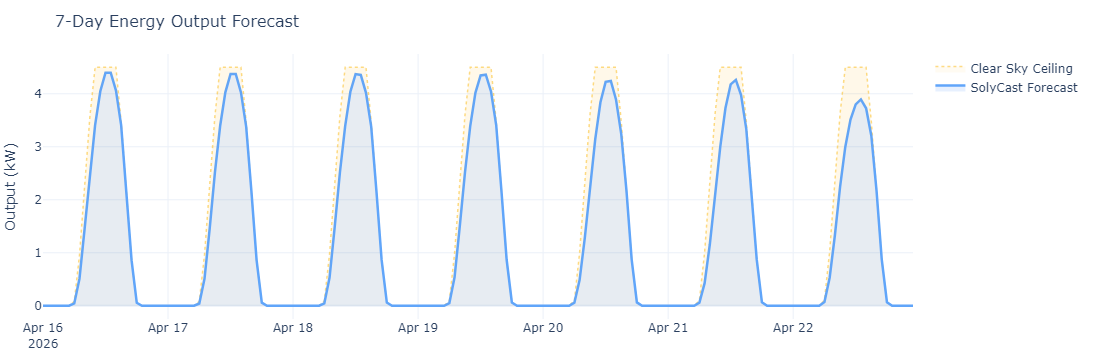

In [22]:
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=data['Time'], y=data['ClearSky_kW'],
    name="Clear Sky Ceiling",
    fill='tozeroy', fillcolor='rgba(251,191,36,0.06)',
    line=dict(color='rgba(251,191,36,0.55)', width=1.5, dash='dot'),
    hovertemplate='%{y:.2f} kW<extra>Clear Sky Ceiling</extra>',
))
fig.add_trace(go.Scatter(
    x=data['Time'], y=data['Predicted_kW'],
    name="SolyCast Forecast",
    fill='tozeroy', fillcolor='rgba(59,130,246,0.12)',
    line=dict(color='#60A5FA', width=2.5),
    hovertemplate='%{y:.2f} kW<extra>SolyCast Forecast</extra>',
))
fig.add_trace(go.Scatter(
    x=list(data['Time']) + list(data['Time'])[::-1],
    y=list(data['ClearSky_kW']) + list(data['Predicted_kW'])[::-1],
    fill='toself', fillcolor='rgba(251,191,36,0.04)',
    line=dict(width=0), showlegend=False, hoverinfo='skip',
))
fig.update_layout(
    title=dict(text="7-Day Energy Output Forecast", font=dict(size=16)),
    yaxis_title="Output (kW)",
    hovermode="x unified",
    legend=dict(orientation="v", x=1.02, y=1, xanchor="left", yanchor="top",
                bgcolor="rgba(0,0,0,0)", borderwidth=0),
    margin=dict(l=10, r=160, t=54, b=10),
    template="plotly_white",
)
fig.show()

## 9 · 7-Day Atmospheric Trends

In [23]:
# ── Daily weather summary table ──
daily = data.groupby('Date').agg(
    MaxTemp=('Temp_C','max'), MinTemp=('Temp_C','min'),
    AvgCloud=('Cloud_Pct','mean'), AvgHumidity=('Humidity','mean'),
    Generation_kWh=('Predicted_kW','sum'),
).round(1).reset_index()
daily['Condition'] = daily['AvgCloud'].apply(
    lambda c: "☀️ Clear" if c < 20 else ("⛅ Partly Cloudy" if c < 70 else "☁️ Overcast"))
display(daily[['Date','Condition','MinTemp','MaxTemp','AvgCloud','AvgHumidity','Generation_kWh']]
        .rename(columns={'MinTemp':'Min °C','MaxTemp':'Max °C',
                         'AvgCloud':'Cloud %','AvgHumidity':'Humidity %',
                         'Generation_kWh':'Generation (kWh)'})
        .style.hide(axis='index'))

Date,Condition,Min °C,Max °C,Cloud %,Humidity %,Generation (kWh)
2026-04-16,☀️ Clear,10.500000,24.200000,4.300000,68.100000,31.300000
2026-04-17,☀️ Clear,10.600000,25.600000,7.300000,69.900000,31.200000
2026-04-18,☀️ Clear,11.100000,26.600000,4.800000,68.300000,31.200000
2026-04-19,☀️ Clear,11.000000,27.300000,4.700000,69.100000,31.300000
2026-04-20,⛅ Partly Cloudy,12.200000,26.100000,69.300000,74.200000,29.700000
2026-04-21,⛅ Partly Cloudy,11.100000,28.300000,30.700000,73.900000,29.300000
2026-04-22,⛅ Partly Cloudy,11.900000,29.500000,49.000000,70.400000,28.400000


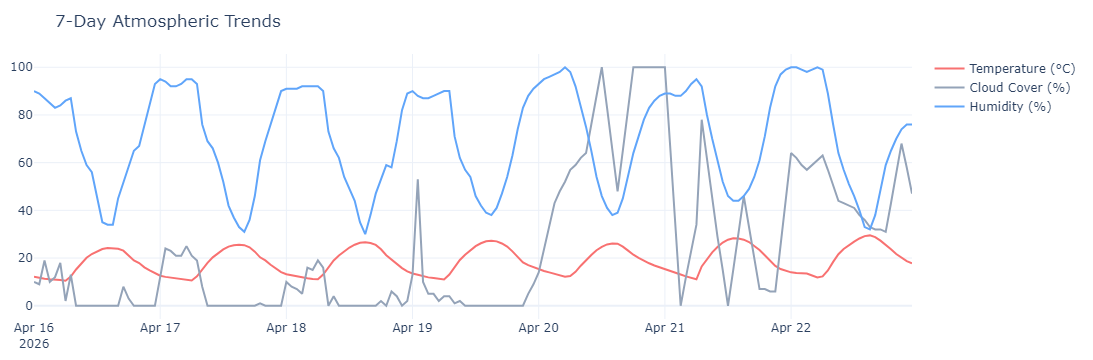

In [24]:
fig_w = go.Figure()
colors_map = {"Temp_C": "#F87171", "Cloud_Pct": "#94A3B8", "Humidity": "#60A5FA"}
labels_map = {"Temp_C": "Temperature (°C)", "Cloud_Pct": "Cloud Cover (%)", "Humidity": "Humidity (%)"}
for col, clr in colors_map.items():
    fig_w.add_trace(go.Scatter(
        x=data['Time'], y=data[col], name=labels_map[col],
        line=dict(color=clr, width=2),
        hovertemplate='%{y:.1f}<extra>' + labels_map[col] + '</extra>',
    ))
fig_w.update_layout(
    title="7-Day Atmospheric Trends", hovermode="x unified",
    legend=dict(orientation="v", x=1.02, y=1, xanchor="left", bgcolor="rgba(0,0,0,0)"),
    margin=dict(l=10, r=160, t=54, b=10), template="plotly_white",
)
fig_w.show()

## 10 · Annual Yield Projection
Simulated from clear-sky physics over a representative mid-month day per month,  
scaled by a latitude-based weather correction factor (0.55–0.82).

In [25]:
monthly_kwh  = compute_annual_yield(LAT, LON, TILT, AZIMUTH, CAPACITY)
months       = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
total_annual = sum(monthly_kwh)
peak_month   = months[monthly_kwh.index(max(monthly_kwh))]

print(f"  Total Annual Yield : {total_annual:,.0f} kWh")
print(f"  Monthly Average    : {total_annual/12:,.0f} kWh")
print(f"  Peak Month         : {peak_month}")
print(f"  Location           : {LAT:.2f}°, {LON:.2f}°")
print(f"  System             : {CAPACITY} kWp  |  Tilt {TILT}°  |  Az {AZIMUTH}° ({az_label})")

  Total Annual Yield : 6,012 kWh
  Monthly Average    : 501 kWh
  Peak Month         : May
  Location           : 35.70°, 0.58°
  System             : 5.0 kWp  |  Tilt 35°  |  Az 180° (S)


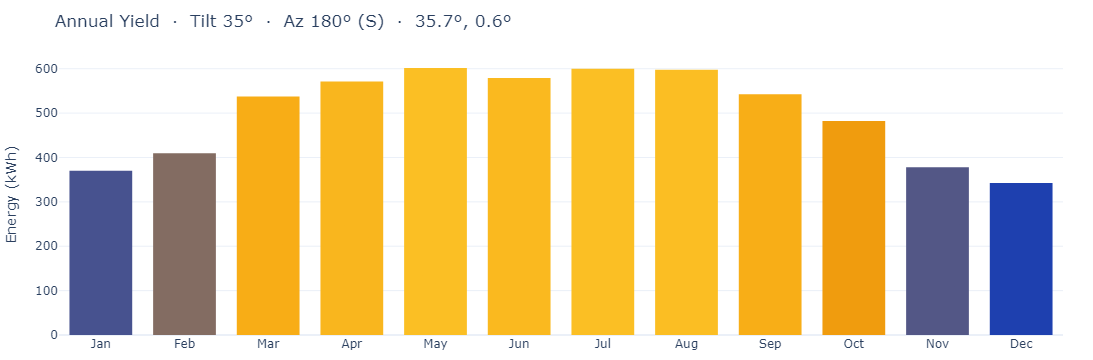

In [26]:
fig_ann = go.Figure(go.Bar(
    x=months, y=monthly_kwh,
    marker=dict(
        color=monthly_kwh,
        colorscale=[[0,'#1E40AF'],[0.55,'#F59E0B'],[1,'#FBBF24']],
        line=dict(width=0),
    ),
    hovertemplate='%{y:,.0f} kWh<extra>%{x}</extra>',
    
))
fig_ann.update_layout(
    title=f"Annual Yield  ·  Tilt {TILT}°  ·  Az {AZIMUTH}° ({az_label})  ·  {LAT:.1f}°, {LON:.1f}°",
    yaxis_title="Energy (kWh)", bargap=0.25,
    template="plotly_white",
    margin=dict(l=10, r=30, t=54, b=10),
)
fig_ann.show()

## 11 · Monthly Breakdown Table

In [27]:
monthly_df = pd.DataFrame({
    'Month':         months,
    'Est. Yield (kWh)': [round(v, 1) for v in monthly_kwh],
    '% of Annual':   [f"{v/total_annual*100:.1f}%" for v in monthly_kwh],
})
display(monthly_df.style.hide(axis='index').bar(
    subset=['Est. Yield (kWh)'], color='#F59E0B', vmin=0))

Month,Est. Yield (kWh),% of Annual
Jan,370.100000,6.2%
Feb,409.400000,6.8%
Mar,537.100000,8.9%
Apr,571.400000,9.5%
May,601.500000,10.0%
Jun,578.800000,9.6%
Jul,600.200000,10.0%
Aug,597.600000,9.9%
Sep,542.700000,9.0%
Oct,482.000000,8.0%


## 12 · Raw Hourly Data

In [28]:
display(data.style.format({
    'Predicted_kW': '{:.3f}', 'ClearSky_kW': '{:.3f}',
    'Temp_C': '{:.1f}', 'Cloud_Pct': '{:.0f}', 'Humidity': '{:.0f}',
}).hide(axis='index'))

Time,Date,Predicted_kW,ClearSky_kW,Temp_C,Cloud_Pct,Humidity,Hour,DayOfWeek,DayNumber,Is_Daylight,Cloud_Atten,CS_Util,Roll3h_kW,Cum_kWh_Day
2026-04-16 00:00:00,2026-04-16,0.000,0.000,12.2,10,90,0,3,1,0,0.900000,0.000000,0.000000,0.000000
2026-04-16 01:00:00,2026-04-16,0.000,0.000,11.6,9,89,1,3,1,0,0.910000,0.000000,0.000000,0.000000
2026-04-16 02:00:00,2026-04-16,0.000,0.000,11.3,19,87,2,3,1,0,0.810000,0.000000,0.000000,0.000000
2026-04-16 03:00:00,2026-04-16,0.000,0.000,11.1,10,85,3,3,1,0,0.900000,0.000000,0.000000,0.000000
2026-04-16 04:00:00,2026-04-16,0.000,0.000,11.1,12,83,4,3,1,0,0.880000,0.000000,0.000000,0.000000
2026-04-16 05:00:00,2026-04-16,0.000,0.000,10.8,18,84,5,3,1,0,0.820000,0.000000,0.014300,0.000000
2026-04-16 06:00:00,2026-04-16,0.043,0.081,10.5,2,86,6,3,1,1,0.980000,0.527800,0.184400,0.042800
2026-04-16 07:00:00,2026-04-16,0.510,0.952,12.2,13,87,7,3,1,1,0.870000,0.536200,0.672400,0.553100
2026-04-16 08:00:00,2026-04-16,1.464,2.272,15.2,0,73,8,3,1,1,1.000000,0.644500,1.493700,2.017200
2026-04-16 09:00:00,2026-04-16,2.507,3.572,17.9,0,65,9,3,1,1,1.000000,0.701700,2.459300,4.524000
